# Point-wise MLP — end-to-end demo

This notebook trains the data-driven point-wise MLP on a small OP subset, evaluates it on
held-out data, runs a short hyperparameter search, and plots the results.

It maps `(x, y, z, t, sim_config)` &rarr; `(T, bc_V)` one spatial point at a time.
See `src/battery_surrogate/model/README.md` for the full API reference.

> The settings below are deliberately small (few OPs, aggressive time subsampling, few epochs)
> so the whole notebook runs quickly on CPU. Increase them for a real run.

## 1. Setup

In [20]:
import sys
from pathlib import Path

# Make the package importable regardless of where the kernel starts.
_here = Path.cwd()
_root = _here.parent if _here.name == "notebooks" else _here
_src = _root / "src"
if _src.exists() and str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import copy
import time

import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from battery_surrogate.data.paths import project_root
from battery_surrogate.data.loader import load_op
from battery_surrogate.model.split import resolve_split
from battery_surrogate.model.normalizer import PointwiseNormalizer
from battery_surrogate.model.dataset_pointwise import PointwiseDataset
from battery_surrogate.model.mlp_pointwise import PointwiseMLP
from battery_surrogate.model.features_pointwise import iter_pointwise_blocks
from battery_surrogate.model.trainer import train_model
from battery_surrogate.model.evaluate import evaluate_on_ops
from battery_surrogate.cli.train_mlp_pointwise import train_from_config, _fit_normalizer

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
print("project root:", project_root())
print("python:", sys.executable)
print("torch:", torch.__version__)

device: cpu
project root: C:\Users\M0245635\batterysurrogatemodell\battery_surrogate_agenticWorkflow
python: c:\Users\M0245635\batterysurrogatemodell\.venv-1\Scripts\python.exe
torch: 2.13.0+cpu


## 2. Config (small, fast demo overrides)

In [21]:
config_path = project_root() / "configs" / "model" / "mlp_pointwise.yaml"
config = yaml.safe_load(config_path.read_text(encoding="utf-8"))

# --- user-facing run switches -----------------------------------------------
# FAST_DEMO=True keeps runtime short for local CPU runs.
# Set FAST_DEMO=False for a more realistic run.
FAST_DEMO = True

# Set RUN_OPTUNA=False if you only want train/eval/plots.
# Set RUN_OPTUNA=True to also run hyperparameter search.
RUN_OPTUNA = True

# --- baseline demo split ----------------------------------------------------
config["data"]["train_ops"] = ["OP01", "OP02"]
config["data"]["val_ops"] = ["OP14"]
config["data"]["test_ops"] = ["OP16"]
config["model"]["n_hidden_layers"] = 3
config["model"]["hidden_size"] = 64
config["train"]["batch_size"] = 4096
config["output"]["ckpt_dir"] = "artifacts/mlp_pointwise_demo/{timestamp}"

if FAST_DEMO:
    config["data"]["subsample_time"] = 300  # faster: fewer timesteps
    config["train"]["epochs"] = 4
else:
    config["data"]["subsample_time"] = 150
    config["train"]["epochs"] = 15

SUBSAMPLE = config["data"]["subsample_time"]
TS_EXTRAP = config["data"]["ts_extrapolation"]

split = resolve_split(config)
print("FAST_DEMO:", FAST_DEMO, "| RUN_OPTUNA:", RUN_OPTUNA)
print("subsample_time:", SUBSAMPLE, "| epochs:", config["train"]["epochs"] )
split

FAST_DEMO: True | RUN_OPTUNA: True
subsample_time: 300 | epochs: 4


{'train': ['OP01', 'OP02'], 'val': ['OP14'], 'test': ['OP16']}

## 3. Fit the normalizer (z-score on train OPs only)

In [22]:
t0 = time.time()
normalizer = _fit_normalizer(
    split["train"], subsample_time=SUBSAMPLE, ts_extrapolation=TS_EXTRAP
)
print(f"fit normalizer on {split['train']} in {time.time() - t0:.1f}s")
print("input mean :", np.round(normalizer.x_mean, 3))
print("output mean:", np.round(normalizer.y_mean, 3), " output std:", np.round(normalizer.y_std, 3))

fit normalizer on ['OP01', 'OP02'] in 0.6s
input mean : [ 1.10000e-02  0.00000e+00 -0.00000e+00  7.12677e+02  2.00000e+00
  3.16000e+02  2.00520e+01  2.00520e+01  1.00000e-03  1.00000e+01
  2.00520e+01]
output mean: [31.605  3.981]  output std: [7.489 0.184]


## 4. Build datasets, loaders and model

In [23]:
train_ds = PointwiseDataset(
    split["train"], normalizer=normalizer, subsample_time=SUBSAMPLE,
    ts_extrapolation=TS_EXTRAP, shuffle_ops=True, shuffle_time=True, seed=42,
)
val_ds = PointwiseDataset(
    split["val"], normalizer=normalizer, subsample_time=SUBSAMPLE,
    ts_extrapolation=TS_EXTRAP, shuffle_ops=False, shuffle_time=False, seed=42,
)

batch_size = config["train"]["batch_size"]
train_loader = DataLoader(train_ds, batch_size=batch_size)
val_loader = DataLoader(val_ds, batch_size=batch_size)

model = PointwiseMLP(
    n_features=11,
    n_hidden_layers=config["model"]["n_hidden_layers"],
    hidden_size=config["model"]["hidden_size"],
    swish_beta_init=config["model"]["swish_beta_init"],
    swish_beta_learnable=config["model"]["swish_beta_learnable"],
)
print(f"n_sensors = {train_ds.n_sensors},  parameters = {model.n_parameters:,}")
print("initial betas:", [round(b, 3) for b in model.betas])

n_sensors = 363,  parameters = 9,605
initial betas: [1.0, 1.0, 1.0]


## 5. Train

In [24]:
t0 = time.time()
print("[train] start")
result = train_model(
    model, train_loader, val_loader, config,
    n_sensors=train_ds.n_sensors, device=DEVICE,
    )
normalizer.save(result.ckpt_dir / "normalizer.json")
print(f"[train] done in {time.time() - t0:.1f}s")
print("best val loss:", round(result.best_val_loss, 6))
print("checkpoint dir:", result.ckpt_dir)
print("final betas:", [round(b, 3) for b in model.betas])

[train] start
[train] done in 5.9s
best val loss: 2.738908
checkpoint dir: artifacts\mlp_pointwise_demo\20260727-132937
final betas: [0.979, 0.991, 1.004]


## 6. Plot: loss curves and learned Swish betas

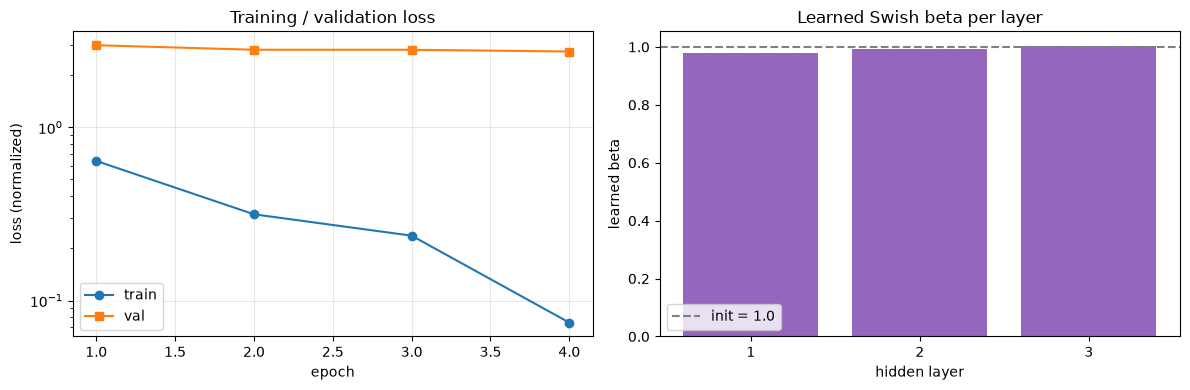

In [25]:
history = result.history
epochs = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history["train_loss"], marker="o", label="train")
ax1.plot(epochs, history["val_loss"], marker="s", label="val")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss (normalized)")
ax1.set_yscale("log"); ax1.set_title("Training / validation loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

betas = model.betas
ax2.bar(range(1, len(betas) + 1), betas, color="tab:purple")
ax2.axhline(1.0, color="gray", ls="--", label="init = 1.0")
ax2.set_xlabel("hidden layer"); ax2.set_ylabel("learned beta")
ax2.set_title("Learned Swish beta per layer")
ax2.set_xticks(range(1, len(betas) + 1)); ax2.legend()

plt.tight_layout(); plt.show()

## 7. Evaluate on the held-out test OP

In [26]:
metrics = evaluate_on_ops(
    model, split["test"], normalizer,
    subsample_time=SUBSAMPLE, ts_extrapolation=TS_EXTRAP, device=DEVICE,
)
print("T   (\u00b0C):", {k: round(v, 4) for k, v in metrics["T"].items()})
print("bc_V (V) :", {k: round(v, 4) for k, v in metrics["bc_V"].items()})
print("bc_V spatial variance (should be ~0):", metrics["bc_V_spatial_variance"])

T   (°C): {'mse': 36.8141, 'mae': 5.0526, 'max_error': 11.8428, 'r2': -0.4132}
bc_V (V) : {'mse': 0.0378, 'mae': 0.1686, 'max_error': 0.5091, 'r2': -0.0284}
bc_V spatial variance (should be ~0): 1.0881205632674154e-07


## 8. Plot: predicted vs. actual over time

Pick one test OP and one sensor, then run the model across all timesteps.

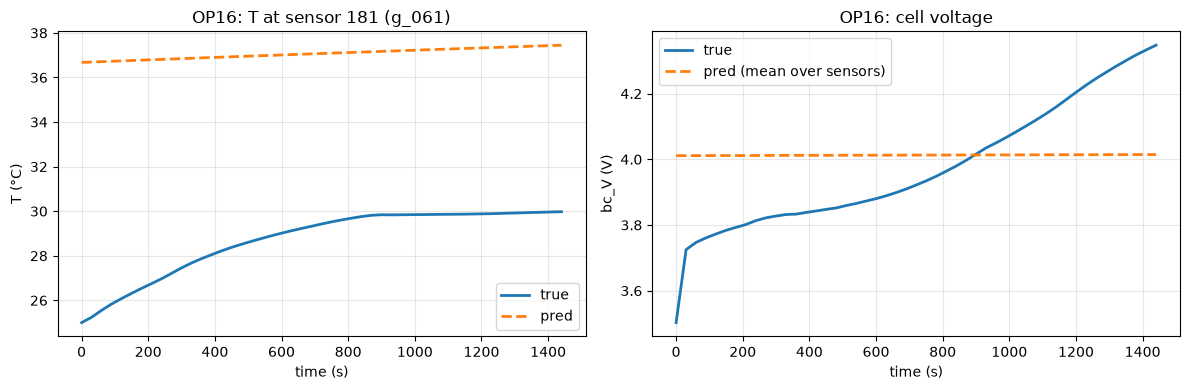

In [27]:
def predict_timeseries(op_id, subsample_time, normalizer, model, device):
    """Return (times, T_true, T_pred, bcV_true, bcV_pred) with shape (n_time, n_sensors) for T."""
    bundle = load_op(op_id)
    time_indices = np.arange(0, bundle.t_fast.shape[0], subsample_time, dtype=np.int64)
    times, T_true, T_pred, bcV_true, bcV_pred = [], [], [], [], []
    model = model.to(device); model.eval()
    with torch.no_grad():
        for x_block, y_block, _sids, ti in iter_pointwise_blocks(
            bundle, time_indices, ts_extrapolation=TS_EXTRAP
        ):
            x_norm = normalizer.transform_X(x_block)
            pred = normalizer.inverse_Y(model(torch.from_numpy(x_norm).to(device)).cpu().numpy())
            times.append(float(bundle.t_fast[ti]))
            T_true.append(y_block[:, 0]); T_pred.append(pred[:, 0])
            bcV_true.append(float(y_block[0, 1])); bcV_pred.append(float(np.mean(pred[:, 1])))
    return (np.array(times), np.array(T_true), np.array(T_pred),
            np.array(bcV_true), np.array(bcV_pred), bundle)


test_op = split["test"][0]
times, T_true, T_pred, bcV_true, bcV_pred, test_bundle = predict_timeseries(
    test_op, SUBSAMPLE, normalizer, model, DEVICE
)
sensor_idx = T_true.shape[1] // 2   # a middle sensor

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(times, T_true[:, sensor_idx], label="true", lw=2)
ax1.plot(times, T_pred[:, sensor_idx], label="pred", ls="--", lw=2)
ax1.set_xlabel("time (s)"); ax1.set_ylabel("T (\u00b0C)")
ax1.set_title(f"{test_op}: T at sensor {sensor_idx} ({test_bundle.sensor_id[sensor_idx]})")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(times, bcV_true, label="true", lw=2)
ax2.plot(times, bcV_pred, label="pred (mean over sensors)", ls="--", lw=2)
ax2.set_xlabel("time (s)"); ax2.set_ylabel("bc_V (V)")
ax2.set_title(f"{test_op}: cell voltage")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Plot: parity and spatial error

Left: predicted vs. true T (parity). Right: absolute T error over the sensor grid at one time.

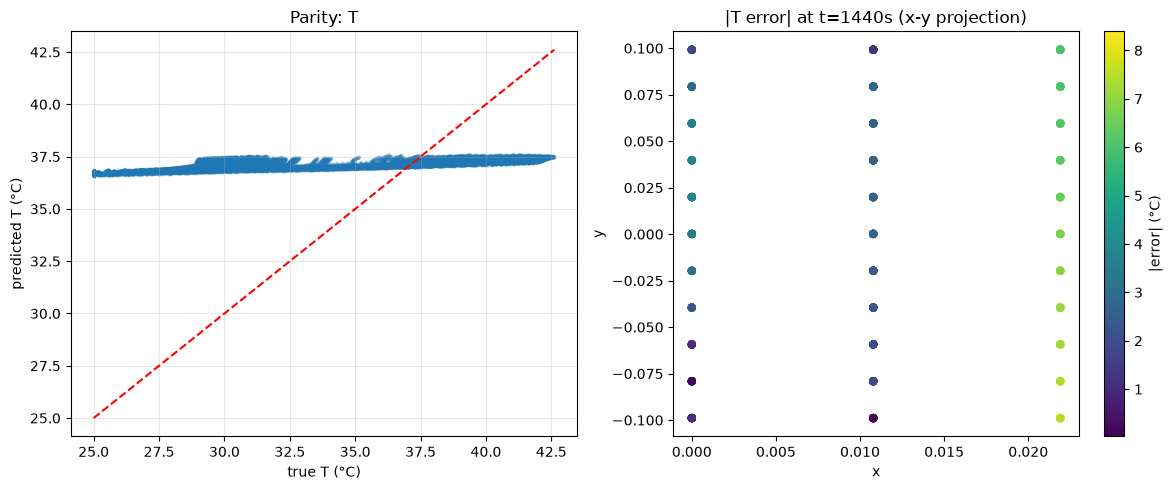

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

flat_true = T_true.ravel(); flat_pred = T_pred.ravel()
lo, hi = float(min(flat_true.min(), flat_pred.min())), float(max(flat_true.max(), flat_pred.max()))
ax1.scatter(flat_true, flat_pred, s=4, alpha=0.2)
ax1.plot([lo, hi], [lo, hi], "r--", lw=1.5)
ax1.set_xlabel("true T (\u00b0C)"); ax1.set_ylabel("predicted T (\u00b0C)")
ax1.set_title("Parity: T"); ax1.grid(True, alpha=0.3)

t_last = -1
abs_err = np.abs(T_pred[t_last] - T_true[t_last])
xyz = test_bundle.xyz
sc = ax2.scatter(xyz[:, 0], xyz[:, 1], c=abs_err, cmap="viridis", s=25)
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.set_title(f"|T error| at t={times[t_last]:.0f}s (x-y projection)")
fig.colorbar(sc, ax=ax2, label="|error| (\u00b0C)")
plt.tight_layout(); plt.show()

## 10. Short hyperparameter search (Optuna)

A tiny study over depth / width / learning rate. Each trial trains a small model on the same
OP subset and reports the best validation loss. Increase `n_trials` and `epochs` for a real search.

In [29]:
study = None

if not RUN_OPTUNA:
    print("[optuna] skipped (RUN_OPTUNA=False)")
else:
    try:
        import optuna
    except ImportError:
        print("[optuna] skipped (package not installed). Install with: pip install optuna")
    else:
        optuna.logging.set_verbosity(optuna.logging.WARNING)

        def objective(trial):
            cfg = copy.deepcopy(config)
            cfg["model"]["n_hidden_layers"] = trial.suggest_int("n_hidden_layers", 2, 4)
            cfg["model"]["hidden_size"] = trial.suggest_categorical("hidden_size", [32, 64, 128])
            cfg["train"]["lr"] = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
            cfg["train"]["epochs"] = 2 if FAST_DEMO else 6
            cfg["output"]["ckpt_dir"] = f"artifacts/mlp_pointwise_optuna/trial_{trial.number}"
            summary = train_from_config(cfg)
            print(f"[optuna] trial={trial.number} best_val_loss={summary['best_val_loss']:.6f}")
            return summary["best_val_loss"]

        n_trials = 2 if FAST_DEMO else 6
        study = optuna.create_study(direction="minimize")
        print(f"[optuna] start n_trials={n_trials}")
        study.optimize(objective, n_trials=n_trials)
        print("best params:", study.best_params)
        print("best val loss:", round(study.best_value, 6))

[optuna] start n_trials=2
[optuna] trial=0 best_val_loss=2.277728
[optuna] trial=1 best_val_loss=2.580201
best params: {'n_hidden_layers': 4, 'hidden_size': 128, 'lr': 0.0007522598431241599}
best val loss: 2.277728


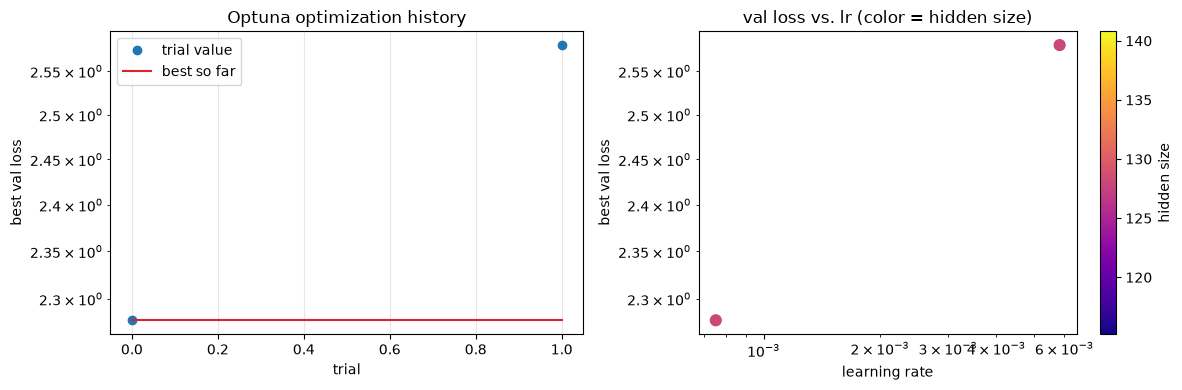

In [30]:
if study is None:
    print("[optuna-plot] skipped (no study)")
else:
    trials = [t for t in study.trials if t.value is not None]
    vals = [t.value for t in trials]
    best_so_far = np.minimum.accumulate(vals)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(range(len(vals)), vals, "o", label="trial value")
    ax1.plot(range(len(vals)), best_so_far, "-", color="tab:red", label="best so far")
    ax1.set_xlabel("trial"); ax1.set_ylabel("best val loss")
    ax1.set_yscale("log"); ax1.set_title("Optuna optimization history")
    ax1.legend(); ax1.grid(True, alpha=0.3)

    sizes = [t.params["hidden_size"] for t in trials]
    lrs = [t.params["lr"] for t in trials]
    sc = ax2.scatter(lrs, vals, c=sizes, cmap="plasma", s=60)
    ax2.set_xscale("log"); ax2.set_xlabel("learning rate"); ax2.set_ylabel("best val loss")
    ax2.set_yscale("log"); ax2.set_title("val loss vs. lr (color = hidden size)")
    fig.colorbar(sc, ax=ax2, label="hidden size")
    plt.tight_layout(); plt.show()

## 11. Takeaways

- The point-wise MLP fits temperature well on in-distribution OPs; `bc_V` is learned as a
  spatially-constant field (check the near-zero spatial variance above).
- For a production run: use the full OP split in `configs/model/mlp_pointwise.yaml`,
  set `subsample_time` back to a small value (or `1`), raise `epochs`, and run the CLI:
  `python -m battery_surrogate.cli.train_mlp_pointwise --config configs/model/mlp_pointwise.yaml`.
- Re-run the Optuna cell with more trials / larger per-trial budget to tune properly.